## This Notebook trains a Neural Network for Galaxy-Matter-Powerspektra Predictions

In [3]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.activations import gelu
from tensorflow.keras.losses import MeanSquaredError
import tensorflow_addons as tfa
import optuna
from tensorflow.keras.layers import LeakyReLU, ELU
import ast

# Für spezielle Aktivierungen wie Swish, GELU
try:
    from tensorflow.keras.activations import swish, gelu
except ImportError:
    # Alternative falls alte TensorFlow-Version
    def swish(x): return x * tf.nn.sigmoid(x)
    def gelu(x): return 0.5 * x * (1.0 + tf.tanh(tf.sqrt(2.0 / tf.constant(np.pi)) * (x + 0.044715 * tf.pow(x, 3))))

# Für AdamW und RAdam Optimizer:
try:
    from tensorflow_addons.optimizers import AdamW, RectifiedAdam
except ImportError:
    # Falls nicht installiert:
    # pip install tensorflow-addons
    print("Installiere tensorflow-addons mit: pip install tensorflow-addons")

2025-08-01 13:44:07.431921: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-01 13:44:08.459044: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-01 13:44:09.897083: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-01 13:44:09.940497: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-01 13:44:26.037890: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [4]:
#%pip install tensorflow
#%pip install pyDOE
#%pip install pandas
#%pip install seaborn
#%pip install tensorflow-addons
#%pip install filelock
#%pip install pyccl

In [5]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [6]:
# setting the seed for reproducibility
np.random.seed(9721)
tf.random.set_seed(9721)

In [7]:
# Get test/training split

N_total=1000000 # Total samples
f_val = 0.00001
f_train=0.00001
f_test= 1-f_val-f_train

# Calculate test and train sample counts
N_test = int(f_test * N_total)
N_train = int(f_train * N_total)
N_val = int(f_val * N_total)

# Generate indices
indices = np.arange(N_total)
np.random.shuffle(indices)

testing_indices=indices[:N_test]
validation_indices = indices[N_test:N_test+N_val]
training_indices = indices[N_test+N_val:N_total]

print(f"Number of test samples is {len(testing_indices)}, should be {N_test}")
print(f"Number of validation samples is {len(validation_indices)}, should be {N_val}")

print(f"Number of train samples is {len(training_indices)}, should be {N_train}")

Number of test samples is 999980, should be 999980
Number of validation samples is 10, should be 10
Number of train samples is 10, should be 10


/tmp/ipykernel_2594313/58162579.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


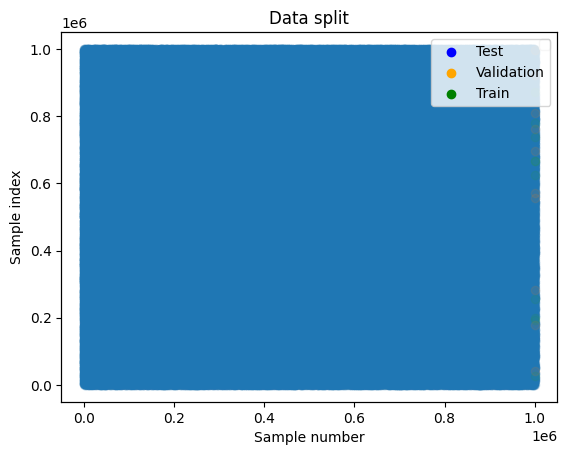

In [8]:
# Plot of test_indices and train_indices
fig, axes=plt.subplots()

plt.scatter(range(N_test), testing_indices, alpha=0.1)
plt.scatter(np.arange(N_val)+N_test, validation_indices, alpha=0.1)
plt.scatter(np.arange(N_train)+N_test+N_val, training_indices, alpha=0.1)

plt.title('Data split')

plt.xlabel('Sample number')
plt.ylabel('Sample index')

ax2=axes.twinx()
ax2.scatter(np.NaN, np.NaN, label='Test', color='blue')
ax2.scatter(np.NaN, np.NaN, label='Validation', color='orange')
ax2.scatter(np.NaN, np.NaN, label='Train', color='green')
ax2.set_yticks([])

axes.legend()
ax2.legend(loc='upper right')
#plt.savefig('../Plots/DataSplit.png', dpi=600)


## Read in generated Targets

In [9]:
# Create directory to save the generated data
data_dir = "../Data/"
os.makedirs(data_dir, exist_ok=True)

In [10]:
# Specifying the storage location of the data
data_dir = "../Data/"

# File path to the saved JSON file
data_fn = f"{data_dir}GeneratedData_1000000_2025-06-11_05-16-31.json"
# read in data
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)

# Define keys needed for Galaxie-Matter
target_keys = [ 
    'Pk_sl_1h', 'Pk_sl_2h', 'Pk_sl'
]

# Create numpy arrays for each of the Pk_* columns
targets_array = {key: np.array([sample[key] for sample in data_samples]) for key in target_keys}


# Logarithmic transformation of the data
def log_transform(targets_array):
    return {key: np.log(data) for key, data in targets_array.items()}

# Calculate logarithms of the data
log_transformed_data = log_transform(targets_array)

# Split the data into training, test and validation sets
training_targets = {}
testing_targets = {}
validation_targets = {}

# Convert dictionaries to NumPy arrays
training_targets['modes'] = np.array([data[:][training_indices] for data in targets_array.values()])
training_targets['targets'] = np.array([data[:][training_indices] for data in log_transformed_data.values()])

validation_targets['modes'] = np.array([data[:][validation_indices] for data in targets_array.values()])
validation_targets['targets'] = np.array([data[:][validation_indices] for data in log_transformed_data.values()])

testing_targets['modes'] = np.array([data[:][testing_indices] for data in targets_array.values()])
testing_targets['targets'] = np.array([data[:][testing_indices] for data in log_transformed_data.values()])

# Define keys needed for linear term
lin_keys = [ 
    'Pk_lin'
]

# Create numpy arrays for linear term
lin_array = {key: np.array([sample[key] for sample in data_samples]) for key in lin_keys}

# Split the linear term data into training, test and validation sets
lin_training_targets = {}
lin_testing_targets = {}
lin_validation_targets = {}

# Convert dictionaries to NumPy arrays
lin_training_targets['modes'] = np.array([data[:][training_indices] for data in lin_array.values()])
lin_training_targets['targets'] = np.array([data[:][training_indices] for data in log_transformed_data.values()])

lin_validation_targets['modes'] = np.array([data[:][validation_indices] for data in lin_array.values()])
lin_validation_targets['targets'] = np.array([data[:][validation_indices] for data in log_transformed_data.values()])

lin_testing_targets['modes'] = np.array([data[:][testing_indices] for data in lin_array.values()])
lin_testing_targets['targets'] = np.array([data[:][testing_indices] for data in log_transformed_data.values()])

In [11]:
print('number of training targets:', len(training_targets['modes'][:][0]), '. Should be', N_train)
print('number of validation targets:', len(validation_targets['modes'][:][0]), '. Should be', N_val)

print('number of test targets:', len(testing_targets['modes'][:][0]), '. Should be', N_test)

number of training targets: 10 . Should be 10
number of validation targets: 10 . Should be 10
number of test targets: 999980 . Should be 999980


In [12]:
N_modes=len(training_targets['modes'])
print(f"Shape of training targets: {training_targets['targets'].shape}. Should be ({N_modes}, {N_train}, 50)")
print(f"Shape of testing targets: {testing_targets['targets'].shape}. Should be ({N_modes}, {N_test}, 50)")
print(f"Shape of validation targets: {validation_targets['targets'].shape}. Should be ({N_modes}, {N_val}, 50)")

Shape of training targets: (3, 10, 50). Should be (3, 10, 50)
Shape of testing targets: (3, 999980, 50). Should be (3, 999980, 50)
Shape of validation targets: (3, 10, 50). Should be (3, 10, 50)


## Read in lin

In [13]:
#print('number of training targets:', len(lin_training_targets['modes'][:][0]), '. Should be', N_train)
#print('number of validation targets:', len(lin_validation_targets['modes'][:][0]), '. Should be', N_val)

#print('number of test targets:', len(lin_testing_targets['modes'][:][0]), '. Should be', N_test)

In [14]:
N_modes=len(lin_training_targets['modes'])
#print(f"Shape of training targets: {lin_training_targets['modes'].shape}. Should be ({N_modes}, {N_train}, 50)")
#print(f"Shape of testing targets: {lin_testing_targets['modes'].shape}. Should be ({N_modes}, {N_test}, 50)")
#print(f"Shape of validation targets: {lin_validation_targets['modes'].shape}. Should be ({N_modes}, {N_val}, 50)")

## Read in related features

In [15]:
para_fn = f"{data_dir}Parameter_1000000_2025-06-11_05-16-31.json"
# Read in
with open(para_fn, "r") as json_file:
    samples = json.load(json_file)


# Create numpy arrays for each of the parameter columns
feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

# List of arrays for each parameter
feature_array = {key: np.array([sample[key] for sample in samples]) for key in feature_keys}

# Split features into training, validation and test data
training_features = {key: feature[training_indices] for key, feature in feature_array.items()}
validation_features = {key: feature[validation_indices] for key, feature in feature_array.items()}
testing_features = {key: feature[testing_indices] for key, feature in feature_array.items()}

training_features = np.array(list(zip(*training_features.values())))
validation_features = np.array(list(zip(*validation_features.values())))
testing_features = np.array(list(zip(*testing_features.values())))


In [16]:
log_indices = [7, 8]  # Ersetze mit deinen echten Indizes

# Nur transformieren, wenn das Array 2D ist und nicht leer
if training_features.ndim == 2 and training_features.shape[0] > 0:
    training_features[:, log_indices] = np.log10(training_features[:, log_indices])
else:
    print("Training-Features: Überspringe log10 – Array ist leer oder nicht 2D")

if validation_features.ndim == 2 and validation_features.shape[0] > 0:
    validation_features[:, log_indices] = np.log10(validation_features[:, log_indices])
else:
    print("Validation-Features: Überspringe log10 – Array ist leer oder nicht 2D")

if testing_features.ndim == 2 and testing_features.shape[0] > 0:
    testing_features[:, log_indices] = np.log10(testing_features[:, log_indices])
else:
    print("Testing-Features: Überspringe log10 – Array ist leer oder nicht 2D")

# Ausgabe der min/max-Werte von training_features
if training_features.ndim == 2 and training_features.size > 0:
    print("input min/max:", training_features.min(), training_features.max())
else:
    print("Training-Features: Keine min/max-Werte – Array ist leer oder nicht 2D")


input min/max: 0.03593945704267147 16.98585792258268


In [17]:
print('number of training features:', len(training_features), '. Should be', N_train)
print('number of validation features:', len(validation_features), '. Should be', N_val)

print('number of test features:', len(testing_features), '. Should be', N_test)

number of training features: 10 . Should be 10
number of validation features: 10 . Should be 10
number of test features: 999980 . Should be 999980


## Cross check
Now, for a cross check we plot the mean of the training, testing and validation data sets. These should all look roughly the same, otherwise we have selected strange test and validation sets.

In [18]:
mean_training_targets = []
std_training_targets = []

mean_testing_targets = []
std_testing_targets = []

mean_validation_targets = []
std_validation_targets = []

# Calculate mean and standard deviation for training targets
for i in range(len(training_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(training_targets['targets'][i])
    
    mean = np.mean(halo_data, axis=0)  # mean over complete training sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete training sample for every k-value
    
    mean_training_targets.append(mean)
    std_training_targets.append(std)

# Calculate mean and standard deviation for testing targets
for i in range(len(testing_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(testing_targets['targets'][i])

    mean = np.mean(halo_data, axis=0) # mean over complete testing sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete testing sample for every k-value

    mean_testing_targets.append(mean)
    std_testing_targets.append(std)

# Calculate mean and standard deviation for validation targets
for i in range(len(validation_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(validation_targets['targets'][i])

    mean = np.mean(halo_data, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_targets.append(mean)
    std_validation_targets.append(std)


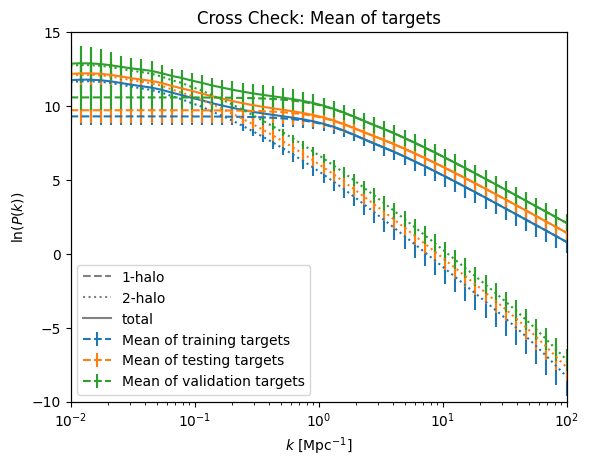

In [19]:
ks = np.geomspace(1e-2, 1e2)

fig, axes=plt.subplots()

plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\ln(P(k))$')
plt.title('Cross Check: Mean of targets')


ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')




ax2.legend(loc='lower left')


plt.xlim(1e-2,100)
plt.ylim(-10, 15)
axes.set_ylim(-10, 15)
ax2.set_yticks([])
axes.set_xscale('log')
axes.set_yscale('linear')


# Plot training targets
plt.errorbar(ks, mean_training_targets[0], ls='--',
             yerr=std_training_targets[0], color='C0', label='Mean of training targets', fmt='')
plt.errorbar(ks, mean_training_targets[1], ls=':', 
             yerr= std_training_targets[1], color='C0', fmt='')
plt.errorbar(ks, mean_training_targets[2], 
             yerr=std_training_targets[2], color='C0', fmt='')

# Plot testing targets
plt.errorbar(ks, mean_testing_targets[0]+0.5, ls='--',
             yerr=std_testing_targets[0], color='C1', label='Mean of testing targets', fmt='')
plt.errorbar(ks, mean_testing_targets[1]+0.5, ls=':', 
             yerr= std_testing_targets[1], color='C1', fmt='')
plt.errorbar(ks, mean_testing_targets[2]+0.5, 
             yerr=std_testing_targets[2], color='C1', fmt='')

# Plot validation targets
plt.errorbar(ks, mean_validation_targets[0]+1, ls='--',
             yerr=std_validation_targets[0], color='C2', label='Mean of validation targets', fmt='')
plt.errorbar(ks, mean_validation_targets[1]+1, ls=':', 
             yerr= std_validation_targets[1], color='C2', fmt='')
plt.errorbar(ks, mean_validation_targets[2]+1, 
             yerr=std_validation_targets[2], color='C2', fmt='')

plt.legend()
plt.savefig('../Plots/CrossCheckTargets.png', dpi=600)
plt.show()

In [20]:
mean_training_features = []
std_training_features = []

mean_testing_features = []
std_testing_features = []

mean_validation_features = []
std_validation_features = []

# Funktion zum sicheren Berechnen von Mittelwert und Standardabweichung
def compute_feature_stats(features, name=""):
    mean_list = []
    std_list = []

    if features.ndim != 2 or features.shape[0] == 0:
        print(f"[{name}] Warnung: Features sind leer oder nicht 2D – Statistik wird übersprungen.")
        return mean_list, std_list

    for i in range(features.shape[1]):  # über alle Spalten iterieren
        feature_parameter = features[:, i]

        mean = np.mean(feature_parameter, axis=0)
        std = np.std(feature_parameter, axis=0)

        mean_list.append(mean)
        std_list.append(std)

    return mean_list, std_list

# Für alle drei Datensätze aufrufen
mean_training_features, std_training_features = compute_feature_stats(training_features, name="Training")
mean_testing_features, std_testing_features = compute_feature_stats(testing_features, name="Testing")
mean_validation_features, std_validation_features = compute_feature_stats(validation_features, name="Validation")


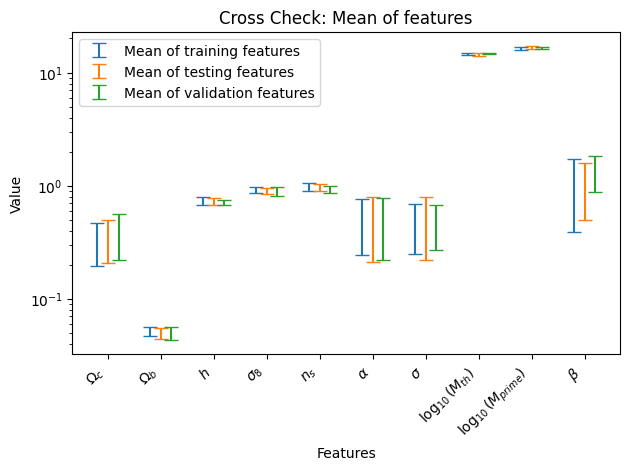

In [21]:
x_pos = np.arange(len(feature_keys))  # numerische Positionen für die x-Werte
offset = 0.2  # Abstand, um die Features ein bisschen zu verschieben

fig, axes = plt.subplots()

axes.set_xlabel('Features')
axes.set_ylabel('Value')
axes.set_title('Cross Check: Mean of features')

# Optional: Y-Achse logarithmisch
axes.set_xscale('linear')
axes.set_yscale('log')

# Training Features
axes.errorbar(x_pos - offset, mean_training_features, 
              yerr=std_training_features, ls='none', 
              color='C0', label='Mean of training features', capsize=5)

# Testing Features
axes.errorbar(x_pos, mean_testing_features, 
              yerr=std_testing_features, ls='none', 
              color='C1', label='Mean of testing features', capsize=5)

# Validation Features
axes.errorbar(x_pos + offset, mean_validation_features, 
              yerr=std_validation_features, ls='none', 
              color='C2', label='Mean of validation features', capsize=5)

# Setze die Original-Feature-Namen als x-Achsen-Beschriftung
axes.set_xticks(x_pos)
axes.set_xticklabels(['$\\Omega_c$', '$\\Omega_b$', '$h$', '$\\sigma_8$', '$n_s$', '$\\alpha$', '$\\sigma$', '$\log_{10}(M_{th})$', '$\log_{10}(M_{prime})$', '$\\beta$' ])
plt.xticks(rotation=45, ha='right')

# Legende
axes.legend()
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Justiere den unteren Rand des Plots
plt.savefig('../Plots/CrossCheckFeatures.png', dpi=600)
plt.show()

feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

## Renaming

In [22]:
# features
train_targets=training_targets['targets']
test_targets=testing_targets['targets']
val_targets=validation_targets['targets']

## Rescaling
We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.


In [23]:
# Calculate mean and standard deviation **only from the training data**
target_processing_vectors = {
    'mean': np.mean(test_targets, axis=1, keepdims=True),
    'sigma': np.std(test_targets, axis=1, keepdims=True)
}

# Ensure that no division by zero occurs
target_processing_vectors['sigma'][target_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(targets, processing_vectors):
    return (targets - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(targets, processing_vectors):
    return targets * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_targets_rescaled = preprocessing(train_targets, target_processing_vectors)
test_targets_rescaled = preprocessing(test_targets, target_processing_vectors)
val_targets_rescaled = preprocessing(val_targets, target_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_targets_rescaled.shape)
print("Test Rescaled Shape:", test_targets_rescaled.shape)
print("Val Rescaled Shape:", val_targets_rescaled.shape)



Train Rescaled Shape: (3, 10, 50)
Test Rescaled Shape: (3, 999980, 50)
Val Rescaled Shape: (3, 10, 50)


In [24]:
mean_training_targets_rescaled = []
std_training_targets_rescaled = []

mean_testing_targets_rescaled = []
std_testing_targets_rescaled = []

mean_validation_targets_rescaled = []
std_validation_targets_rescaled = []

# Calculate mean and standard deviation for rescaled training targets
for i in range(len(train_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(train_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled training sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled training sample for every k-value

    mean_training_targets_rescaled.append(mean)
    std_training_targets_rescaled.append(std)

# Calculate mean and standard deviation for rescaled testing targets
for i in range(len(test_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(test_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled testing sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled testing sample for every k-value

    mean_testing_targets_rescaled.append(mean)
    std_testing_targets_rescaled.append(std)

# Calculate mean and standard deviation for rescaled validation targets
for i in range(len(val_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(val_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled validation sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled validation sample for every k-value

    mean_validation_targets_rescaled.append(mean)
    std_validation_targets_rescaled.append(std)

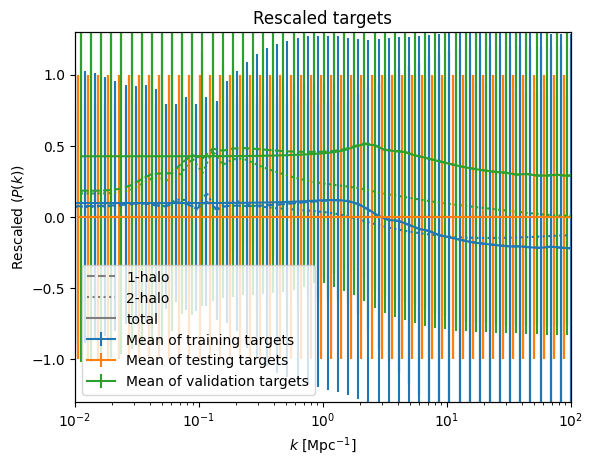

In [25]:
fig, axes=plt.subplots()
#axes.loglog(ks, Pk_lin, color='k', label='linear')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'Rescaled $(P(k))$')
plt.title('Rescaled targets')

ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')
ax2.set_yticks([])



plt.errorbar(ks,mean_training_targets_rescaled[0], 
             yerr=std_training_targets_rescaled[0], color='C0', label='Mean of training targets')
plt.errorbar(ks,mean_training_targets_rescaled[1], ls=':', 
             yerr=std_training_targets_rescaled[1], color='C0')
plt.errorbar(ks,mean_training_targets_rescaled[2], ls='--', 
             yerr=std_training_targets_rescaled[2], color='C0')

plt.errorbar(ks*1.06,mean_testing_targets_rescaled[0], 
             yerr=std_testing_targets_rescaled[0], color='C1', label='Mean of testing targets')
plt.errorbar(ks*1.06,mean_testing_targets_rescaled[1], ls=':', 
             yerr=std_testing_targets_rescaled[1], color='C1')
plt.errorbar(ks*1.06,mean_testing_targets_rescaled[2], ls='--', 
             yerr=std_testing_targets_rescaled[2], color='C1')

plt.errorbar(ks*1.12,mean_validation_targets_rescaled[0], 
             yerr=std_validation_targets_rescaled[0], color='C2', label='Mean of validation targets')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[1], ls=':', 
             yerr=std_validation_targets_rescaled[1], color='C2')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[2], ls='--', 
             yerr=std_validation_targets_rescaled[2], color='C2')

axes.set_ylim(-1.3, 1.3)
plt.xlim(1e-2,100)
plt.ylim(-1.3,1.3)
plt.xscale('log')
plt.legend()
plt.savefig('../Plots/RescaledTargets.png', dpi=600)

In [26]:
# Calculate mean and standard deviation **only from the training data**
feature_processing_vectors = {
    'mean': np.array(mean_testing_features).reshape(1, -1),
    'sigma': np.array(std_testing_features).reshape(1, -1)
}


# Ensure that no division by zero occurs
feature_processing_vectors['sigma'][feature_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(features, processing_vectors):
    return (features - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(features, processing_vectors):
    return features * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_features_rescaled = preprocessing(training_features, feature_processing_vectors)
test_features_rescaled = preprocessing(testing_features, feature_processing_vectors)
val_features_rescaled = preprocessing(validation_features, feature_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_features_rescaled.shape)
print("Test Rescaled Shape:", test_features_rescaled.shape)
print("Val Rescaled Shape:", val_features_rescaled.shape)



Train Rescaled Shape: (10, 10)
Test Rescaled Shape: (999980, 10)
Val Rescaled Shape: (10, 10)


In [27]:


mean_training_features_rescaled = []
std_training_features_rescaled = []

mean_testing_features_rescaled = []
std_testing_features_rescaled = []

mean_validation_features_rescaled = []
std_validation_features_rescaled = []


# Calculate mean and standard deviation for training features
for i in range(len(train_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(train_features_rescaled[:,i])
    
    mean = np.mean(feature_parameter, axis=0)  # mean over complete training sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete training sample for every k-value
    mean_training_features_rescaled.append(mean)
    std_training_features_rescaled.append(std)

# Calculate mean and standard deviation for testing features
for i in range(len(test_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(test_features_rescaled[:,i])

    mean = np.mean(feature_parameter, axis=0) # mean over complete testing sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete testing sample for every k-value

    mean_testing_features_rescaled.append(mean)
    std_testing_features_rescaled.append(std)

# Calculate mean and standard deviation for validation features
for i in range(len(val_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(val_features_rescaled[:,i])

    mean = np.mean(feature_parameter, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_features_rescaled.append(mean)
    std_validation_features_rescaled.append(std)

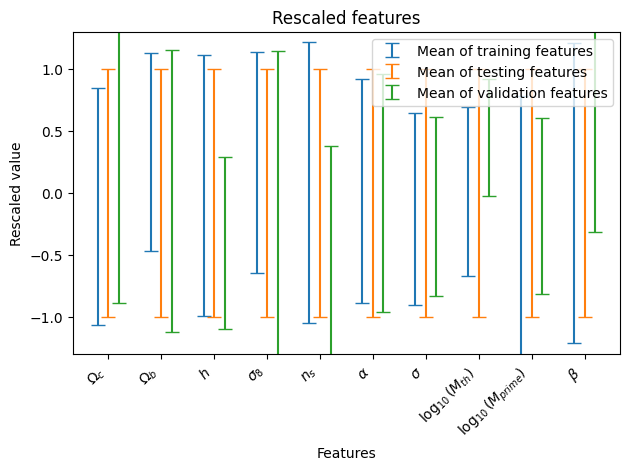

In [28]:
x_pos = np.arange(len(feature_keys))  # numerische Positionen für die x-Werte
offset = 0.2  # Abstand, um die Features ein bisschen zu verschieben

fig, axes = plt.subplots()

axes.set_xlabel('Features')
axes.set_ylabel('Rescaled value')
axes.set_title('Rescaled features')

# Optional: Y-Achse logarithmisch
axes.set_xscale('linear')
axes.set_yscale('linear')

# Training Features
axes.errorbar(x_pos - offset, mean_training_features_rescaled, 
              yerr=std_training_features_rescaled, ls='none', 
              color='C0', label='Mean of training features', capsize=5)

# Testing Features
axes.errorbar(x_pos, mean_testing_features_rescaled, 
              yerr=std_testing_features_rescaled, ls='none', 
              color='C1', label='Mean of testing features', capsize=5)

# Validation Features
axes.errorbar(x_pos + offset, mean_validation_features_rescaled, 
              yerr=std_validation_features_rescaled, ls='none', 
              color='C2', label='Mean of validation features', capsize=5)

# Setze die Original-Feature-Namen als x-Achsen-Beschriftung
axes.set_xticks(x_pos)
axes.set_xticklabels(['$\\Omega_c$', '$\\Omega_b$', '$h$', '$\\sigma_8$', '$n_s$', '$\\alpha$', '$\\sigma$', '$\log_{10}(M_{th})$', '$\log_{10}(M_{prime})$', '$\\beta$' ])
plt.xticks(rotation=45, ha='right')


axes.set_ylim(-1.3, 1.3)
plt.ylim(-1.3,1.3)
# Legende
plt.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Justiere den unteren Rand des Plots
plt.savefig('../Plots/RescaledFeatures.png', dpi=600)
plt.show()

## NN training

### Define Model

Define Neural Network with following structure

In [29]:
#restructuring of the arrays
train_targets_rescaled      = np.transpose(train_targets_rescaled, (1, 0, 2))
val_targets_rescaled  = np.transpose(val_targets_rescaled, (1, 0, 2))
test_targets_rescaled = np.transpose(test_targets_rescaled, (1, 0, 2))


In [30]:
import re
input_file = '../exampleBayesianGM/training_runsv5.txt'
output_file = 'test_losses.txt'

# Speicher für Ergebnisse
results = []

# Datei zeilenweise einlesen
with open(input_file, 'r') as file:
    lines = file.readlines()

for line in lines:
    line = line.strip()
    
    # Datum extrahieren mit RegEx
    match = re.match(r'^(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})', line)
    if not match:
        continue  # Zeile überspringen, wenn kein Datum
    model_date = match.group(1)

    model_path = f'../NN_builds/NN_{model_date}.keras'

    # Prüfen, ob das Modell existiert
    if not os.path.exists(model_path):
        print(f"Modell nicht gefunden: {model_path}")
        continue

    try:
        # Modell laden
        model = keras.models.load_model(model_path, compile=False)
        model.compile(optimizer=RectifiedAdam(), loss='mse')

        # Loss auf Testdaten berechnen
        test_loss = model.evaluate(
            test_features_rescaled,
            test_targets_rescaled.reshape((N_test, 150)),
            batch_size=N_total,
            verbose=0
        )

        # Ergebnis merken
        results.append((model_date, test_loss))
        print(f"{model_date}: test loss = {test_loss:.6f}")

    except Exception as e:
        print(f"Fehler beim Verarbeiten von {model_date}: {e}")
        continue

# Ergebnisse speichern
with open(output_file, 'w') as f:
    for model_date, loss in results:
        f.write(f"{model_date}, test_loss={loss:.6f}\n")

print(f"\nErgebnisse in '{output_file}' gespeichert.")

2025-07-03_07-15-12: test loss = 0.004432
2025-07-03_17-54-55: test loss = 1.000000
2025-07-07_00-26-22: test loss = 0.003670
2025-07-07_10-50-21: test loss = 0.005987
2025-07-08_00-29-51: test loss = 0.070034
2025-07-10_13-21-38: test loss = 0.002064
2025-07-11_19-05-49: test loss = 1.000020
2025-07-11_21-18-49: test loss = 0.001819
2025-07-12_09-35-02: test loss = 0.001807
2025-07-14_10-33-06: test loss = 0.005778
2025-07-14_10-58-34: test loss = 0.038304
2025-07-14_16-15-17: test loss = 0.001709
2025-07-15_08-36-47: test loss = 0.006466
2025-07-19_12-47-40: test loss = 1.000098
2025-07-20_07-38-56: test loss = 0.003339
2025-07-20_12-50-01: test loss = 0.004101
2025-07-20_13-04-34: test loss = 0.070547
2025-07-20_17-56-24: test loss = 0.028720
2025-07-21_12-15-00: test loss = 0.006408
2025-07-22_05-38-00: test loss = 0.016571
2025-07-22_18-47-40: test loss = 0.002503
2025-07-23_02-34-50: test loss = 0.001421
2025-07-23_17-58-36: test loss = 0.001173
2025-07-24_06-38-56: test loss = 0

In [31]:
# ➕ Bestes Modell ermitteln (kleinster Test Loss)
if results:
    best_model = min(results, key=lambda x: x[1])
    print(f"\n✅ Bestes Modell: {best_model[0]} mit Test Loss = {best_model[1]:.6f}")
else:
    print("⚠️ Keine gültigen Modelle gefunden.")



✅ Bestes Modell: 2025-07-26_07-40-16 mit Test Loss = 0.001038


In [33]:
import ast

best_model = None
best_test_loss = float('inf')

# Ergebnisse aus vorherigem Block (z. B. geladen oder weiterverwendet)
# results = [(model_date, test_loss), ...]

# Öffne die Datei mit Hyperparametern
with open("../exampleBayesianGM/training_runsv5.txt", "r") as f:
    training_lines = f.readlines()

# Durchlaufe alle test_loss-Ergebnisse
for model_date, test_loss in results:
    matching_lines = [line for line in training_lines if line.startswith(model_date)]
    if not matching_lines:
        print(f"⚠️ Kein Eintrag für {model_date} in training_runsv3.txt gefunden.")
        continue

    line = matching_lines[0]
    try:
        # Extrahiere Hyperparameter-Dictionary
        params_str = line.split("params=")[1].strip()
        params = ast.literal_eval(params_str)

        # Prüfe Anzahl der Layer
        if params.get("n_layers", 999) <= 3:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                best_model = (line.strip(), params, test_loss)
    except Exception as e:
        print(f"⚠️ Fehler beim Verarbeiten von {model_date}:\n{e}")

# Ergebnis anzeigen
if best_model:
    print("\n✅ Bestes Modell mit ≤ 3 Layern:")
    print(best_model[0])
    print(f"\n🔢 n_layers = {best_model[1]['n_layers']}")
    print(f"📉 test_loss = {best_model[2]:.6f}")
else:
    print("❌ Kein Modell mit ≤ 3 Layern gefunden.")



✅ Bestes Modell mit ≤ 3 Layern:
2025-07-26_07-40-16 test_loss=0.000958, validation loss=0.000878, loss=0.000193, train_mae=0.007498, val_mae=0.008354, test_mae=0.008327, params={'n_layers': 3, 'n_units': 1604, 'activation': 'elu', 'optimizer': 'adam', 'lr': 0.000609142338825873, 'batchsize': 762, 'dropout_rate': 0.11057236314642602}

🔢 n_layers = 3
📉 test_loss = 0.001038


In [34]:
input_file = '../exampleBayesianGM/training_runsv5_1halo.txt'
output_file = 'test_losses1halo.txt'

# Speicher für Ergebnisse
results = []

# Datei zeilenweise einlesen
with open(input_file, 'r') as file:
    lines = file.readlines()

for line in lines:
    line = line.strip()
    
    # Datum extrahieren mit RegEx
    match = re.match(r'^(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})', line)
    if not match:
        continue  # Zeile überspringen, wenn kein Datum
    model_date = match.group(1)

    model_path = f'../NN_builds/NN_{model_date}.keras'

    # Prüfen, ob das Modell existiert
    if not os.path.exists(model_path):
        print(f"Modell nicht gefunden: {model_path}")
        continue

    try:
        # Modell laden
        model = keras.models.load_model(model_path, compile=False)
        model.compile(optimizer=RectifiedAdam(), loss='mse')

        # Loss auf Testdaten berechnen
        test_loss = model.evaluate(
            test_features_rescaled,
            test_targets_rescaled.reshape((N_test, 150))[:, :50],
            batch_size=N_total,
            verbose=0
        )

        # Ergebnis merken
        results.append((model_date, test_loss))
        print(f"{model_date}: test loss = {test_loss:.6f}")

    except Exception as e:
        print(f"Fehler beim Verarbeiten von {model_date}: {e}")
        continue

# Ergebnisse speichern
with open(output_file, 'w') as f:
    for model_date, loss in results:
        f.write(f"{model_date}, test_loss={loss:.6f}\n")

print(f"\nErgebnisse in '{output_file}' gespeichert.")

2025-07-03_11-41-22: test loss = 0.005494
2025-07-03_14-26-40: test loss = 0.003760
2025-07-03_22-30-04: test loss = 0.008040
2025-07-04_03-12-48: test loss = 0.123893
2025-07-05_07-37-17: test loss = 0.007990
2025-07-05_13-13-15: test loss = 0.024383
2025-07-08_03-43-41: test loss = 0.002639
2025-07-08_05-55-41: test loss = 0.014349
2025-07-08_08-37-00: test loss = 0.035789
2025-07-08_15-11-03: test loss = 0.012692
2025-07-09_16-21-34: test loss = 0.066061
2025-07-13_02-39-43: test loss = 1.000002
2025-07-13_20-38-33: test loss = 0.017144
2025-07-14_13-10-00: test loss = 0.002937
2025-07-15_00-55-30: test loss = 0.012481
2025-07-15_17-37-51: test loss = 0.003632
2025-07-16_21-40-56: test loss = 0.002488
2025-07-17_16-24-33: test loss = 0.005624
2025-07-18_00-21-57: test loss = 0.072533
2025-07-18_14-48-06: test loss = 0.011827
2025-07-19_03-29-54: test loss = 1.000001
2025-07-19_16-33-53: test loss = 0.003516
2025-07-21_08-53-00: test loss = 0.007414
2025-07-22_10-36-04: test loss = 0

In [35]:
# ➕ Bestes Modell ermitteln (kleinster Test Loss)
if results:
    best_model = min(results, key=lambda x: x[1])
    print(f"\n✅ Bestes Modell: {best_model[0]} mit Test Loss = {best_model[1]:.6f}")
else:
    print("⚠️ Keine gültigen Modelle gefunden.")


✅ Bestes Modell: 2025-07-23_18-02-10 mit Test Loss = 0.001778


In [36]:
import ast

best_model = None
best_test_loss = float('inf')

# Ergebnisse aus vorherigem Block (z. B. geladen oder weiterverwendet)
# results = [(model_date, test_loss), ...]

# Öffne die Datei mit Hyperparametern
with open("../exampleBayesianGM/training_runsv5_1halo.txt", "r") as f:
    training_lines = f.readlines()

# Durchlaufe alle test_loss-Ergebnisse
for model_date, test_loss in results:
    matching_lines = [line for line in training_lines if line.startswith(model_date)]
    if not matching_lines:
        print(f"⚠️ Kein Eintrag für {model_date} in training_runs_1halo.txt gefunden.")
        continue

    line = matching_lines[0]
    try:
        # Extrahiere Hyperparameter-Dictionary
        params_str = line.split("params=")[1].strip()
        params = ast.literal_eval(params_str)

        # Prüfe Anzahl der Layer
        if params.get("n_layers", 999) <= 3:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                best_model = (line.strip(), params, test_loss)
    except Exception as e:
        print(f"⚠️ Fehler beim Verarbeiten von {model_date}:\n{e}")

# Ergebnis anzeigen
if best_model:
    print("\n✅ Bestes Modell mit ≤ 3 Layern:")
    print(best_model[0])
    print(f"\n🔢 n_layers = {best_model[1]['n_layers']}")
    print(f"📉 test_loss = {best_model[2]:.6f}")
else:
    print("❌ Kein Modell mit ≤ 3 Layern gefunden.")



✅ Bestes Modell mit ≤ 3 Layern:
2025-07-03_14-26-40 test_loss=0.003886, validation loss=0.004186, loss=0.002343, train_mae=0.012838, val_mae=0.013594, test_mae=0.013543, params={'n_layers': 2, 'n_units': 1522, 'activation': 'gelu', 'optimizer': 'adam', 'lr': 6.622975192348541e-05, 'batchsize': 1375, 'dropout_rate': 0.19312580482180064}

🔢 n_layers = 2
📉 test_loss = 0.003760


In [37]:
input_file = '../exampleBayesianGM/training_runsv5_2halo.txt'
output_file = 'test_losses2halo.txt'

# Speicher für Ergebnisse
results = []

# Datei zeilenweise einlesen
with open(input_file, 'r') as file:
    lines = file.readlines()

for line in lines:
    line = line.strip()
    
    # Datum extrahieren mit RegEx
    match = re.match(r'^(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})', line)
    if not match:
        continue  # Zeile überspringen, wenn kein Datum
    model_date = match.group(1)

    model_path = f'../NN_builds/NN_{model_date}.keras'

    # Prüfen, ob das Modell existiert
    if not os.path.exists(model_path):
        print(f"Modell nicht gefunden: {model_path}")
        continue

    try:
        # Modell laden
        model = keras.models.load_model(model_path, compile=False)
        model.compile(optimizer=RectifiedAdam(), loss='mse')

        # Loss auf Testdaten berechnen
        test_loss = model.evaluate(
            test_features_rescaled,
            test_targets_rescaled.reshape((N_test, 150))[:, 50:100],
            batch_size=N_total,
            verbose=0
        )

        # Ergebnis merken
        results.append((model_date, test_loss))
        print(f"{model_date}: test loss = {test_loss:.6f}")

    except Exception as e:
        print(f"Fehler beim Verarbeiten von {model_date}: {e}")
        continue

# Ergebnisse speichern
with open(output_file, 'w') as f:
    for model_date, loss in results:
        f.write(f"{model_date}, test_loss={loss:.6f}\n")

print(f"\nErgebnisse in '{output_file}' gespeichert.")

2025-07-02_18-37-27: test loss = 0.028426
2025-07-03_08-16-56: test loss = 0.004769
2025-07-04_16-12-12: test loss = 0.007511
2025-07-16_18-53-02: test loss = 0.001422
2025-07-17_00-28-25: test loss = 0.004784
2025-07-18_05-39-06: test loss = 1.000005
2025-07-18_13-34-30: test loss = 0.001021
2025-07-20_11-08-33: test loss = 0.002184
2025-07-20_18-33-31: test loss = 0.114523
2025-07-20_19-43-07: test loss = 1.000003
2025-07-21_12-49-59: test loss = 0.012473
2025-07-21_18-12-51: test loss = 0.015290
2025-07-22_12-01-44: test loss = 3.716172
2025-07-22_15-23-25: test loss = 0.002581
2025-07-23_06-59-21: test loss = 0.000853

Ergebnisse in 'test_losses2halo.txt' gespeichert.


In [38]:
# ➕ Bestes Modell ermitteln (kleinster Test Loss)
if results:
    best_model = min(results, key=lambda x: x[1])
    print(f"\n✅ Bestes Modell: {best_model[0]} mit Test Loss = {best_model[1]:.6f}")
else:
    print("⚠️ Keine gültigen Modelle gefunden.")


✅ Bestes Modell: 2025-07-23_06-59-21 mit Test Loss = 0.000853


In [39]:
import ast

best_model = None
best_test_loss = float('inf')

# Ergebnisse aus vorherigem Block (z. B. geladen oder weiterverwendet)
# results = [(model_date, test_loss), ...]

# Öffne die Datei mit Hyperparametern
with open("../exampleBayesianGM/training_runsv5_2halo.txt", "r") as f:
    training_lines = f.readlines()

# Durchlaufe alle test_loss-Ergebnisse
for model_date, test_loss in results:
    matching_lines = [line for line in training_lines if line.startswith(model_date)]
    if not matching_lines:
        print(f"⚠️ Kein Eintrag für {model_date} in training_runs_2halo.txt gefunden.")
        continue

    line = matching_lines[0]
    try:
        # Extrahiere Hyperparameter-Dictionary
        params_str = line.split("params=")[1].strip()
        params = ast.literal_eval(params_str)

        # Prüfe Anzahl der Layer
        if params.get("n_layers", 999) <= 3:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                best_model = (line.strip(), params, test_loss)
    except Exception as e:
        print(f"⚠️ Fehler beim Verarbeiten von {model_date}:\n{e}")

# Ergebnis anzeigen
if best_model:
    print("\n✅ Bestes Modell mit ≤ 3 Layern:")
    print(best_model[0])
    print(f"\n🔢 n_layers = {best_model[1]['n_layers']}")
    print(f"📉 test_loss = {best_model[2]:.6f}")
else:
    print("❌ Kein Modell mit ≤ 3 Layern gefunden.")



✅ Bestes Modell mit ≤ 3 Layern:
2025-07-17_00-28-25 test_loss=0.004913, validation loss=0.005190, loss=0.004218, train_mae=0.041080, val_mae=0.042563, test_mae=0.042121, params={'n_layers': 2, 'n_units': 372, 'activation': 'relu', 'optimizer': 'RAdam', 'lr': 0.00026744049739359585, 'batchsize': 445, 'dropout_rate': 0.4981498769272053}

🔢 n_layers = 2
📉 test_loss = 0.004784


In [40]:
test_losses = []
with open("test_losses.txt", "r") as f:
    for line in f:
        test_loss_str = line.split("test_loss=")[1].strip()
        test_loss = float(test_loss_str)
        test_losses.append(test_loss)

In [41]:
import ast

results = []

with open("out/training_runsv3.txt", "r") as f:
    for idx, line in enumerate(f):
        val_loss_str = line.split("validation loss=")[1].split(",")[0]
        val_loss = float(val_loss_str)

        params_str = line.split("params=")[1].strip()
        params = ast.literal_eval(params_str)

        test_loss = test_losses[idx]  # gleiche Reihenfolge!

        results.append((params, val_loss, test_loss))


IndexError: list index out of range

In [ ]:
for i in range(5):
    print(results[i])

({'n_layers': 1, 'n_units': 261, 'activation': 'leaky_relu', 'optimizer': 'AdamW', 'lr': 0.002026873797471395, 'batchsize': 973}, 0.009401, 0.00929)
({'n_layers': 4, 'n_units': 35, 'activation': 'tanh', 'optimizer': 'RAdam', 'lr': 0.0027181747209319685, 'batchsize': 550}, 0.000997, 0.002712)
({'n_layers': 8, 'n_units': 95, 'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.002266262652592875, 'batchsize': 1392}, 0.00231, 0.002785)
({'n_layers': 1, 'n_units': 260, 'activation': 'selu', 'optimizer': 'rmsprop', 'lr': 0.005529074040732428, 'batchsize': 1597}, 0.008075, 0.007563)
({'n_layers': 6, 'n_units': 287, 'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.00048583821060752176, 'batchsize': 159}, 0.003818, 0.003778)


/tmp/ipykernel_2932616/1278076608.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(lim_low, lim_high)
/tmp/ipykernel_2932616/1278076608.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(lim_low, lim_high)
/tmp/ipykernel_2932616/1278076608.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(lim_low, lim_high)
/tmp/ipykernel_2932616/1278076608.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(lim_low, lim_high)
/tmp/ipykernel_2932616/1278076608.py:106: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(lim_low, lim_high)


Anzahl der analysierten Netzwerke: 662


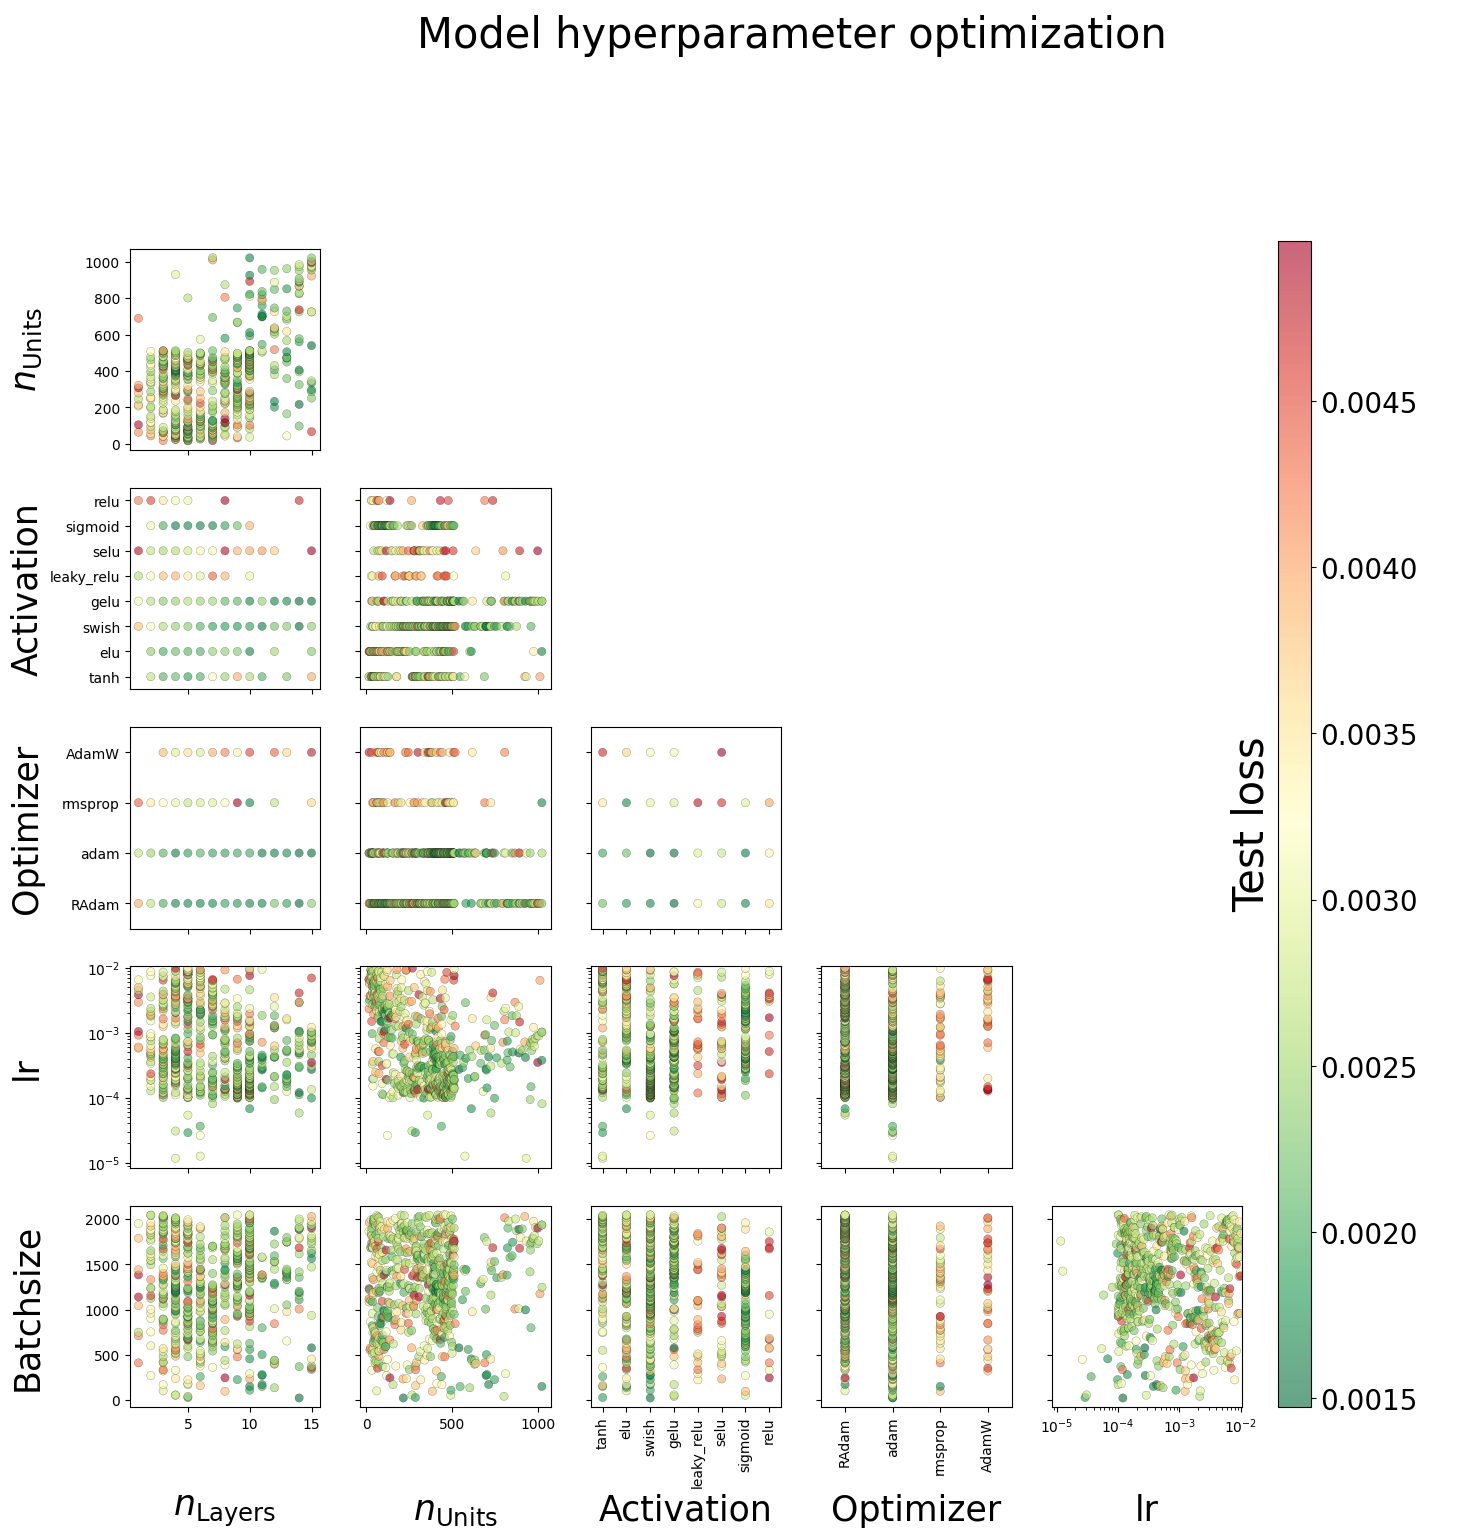

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Threshold definieren
TEST_LOSS_THRESHOLD = 1

# results ist Liste von Tupeln: (params_dict, val_loss, test_loss)

# 1. Filtere gültige Optimizer-Kombinationen mit test_loss < THRESHOLD
allowed_optimizers = {
    p['optimizer']
    for p, _, test_loss in results
    if test_loss < TEST_LOSS_THRESHOLD
}

# 2. Filtere alle Ergebnisse, die zu diesen Optimizern gehören
filtered_results = [
    (p, test_loss)
    for p, _, test_loss in results
    if p['optimizer'] in allowed_optimizers
]

# 3. DataFrame aus den gefilterten Ergebnissen
df = pd.DataFrame([p for p, _ in filtered_results])
df["test_loss"] = [v for _, v in filtered_results]

# 4. Filter: nur Einträge mit test_loss < 0.005 behalten
df = df[df["test_loss"] < 0.005]

# Parameterbeschriftungen (für Achsen)
param_names = [r'$n_\mathrm{Layers}$', r'$n_\mathrm{Units}$', r'Activation', r'Optimizer', r'lr', r'Batchsize']

# Kategorische Spalten numerisch kodieren
categorical_columns = ["activation", "optimizer"]
label_maps = {}

for col in categorical_columns:
    unique_vals = df[col].unique()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    df[col] = df[col].map(mapping)
    label_maps[col] = {i: val for val, i in mapping.items()}

# NumPy-Arrays erzeugen
input_parameters = df.drop(columns=["test_loss"]).values
test_loss = df["test_loss"].values

# Plot-Funktion
def corner_plot(input_parameters, param_names, test_loss, label_maps):
    n_samples, n_params = input_parameters.shape
    fig, axes = plt.subplots(n_params, n_params, figsize=(2.7 * n_params, 2.7 * n_params), sharex='col', sharey='row')

    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            elif i == j:
                ax.axis("off")  # Histogramm entfernen

            else:
                x = input_parameters[:, j]
                y = input_parameters[:, i]

                # Deduplizieren: Für jedes (x,y)-Paar nur den minimalen test_loss behalten
                df_points = pd.DataFrame({'x': x, 'y': y, 'test_loss': test_loss})
                df_min = df_points.groupby(['x', 'y'], as_index=False).min()

                x_dedup = df_min['x'].values
                y_dedup = df_min['y'].values
                test_loss_dedup = df_min['test_loss'].values

                sc = ax.scatter(x_dedup, y_dedup,
                                c=test_loss_dedup,
                                cmap="RdYlGn_r",
                                alpha=0.6,
                                edgecolor="k", linewidth=0.2)

                for axis, arr, idx in zip(['x', 'y'], [x_dedup, y_dedup], [j, i]):
                    param_key = param_names[idx].strip('$').lower()
                    if len(arr) == 0:
                        continue
                    min_val, max_val = np.min(arr), np.max(arr)

                    if param_key in label_maps:
                        ticks = sorted(label_maps[param_key].keys())
                        labels = [label_maps[param_key][t] for t in ticks]
                        lim_low = min_val - 0.5
                        lim_high = max_val + 0.5
                    else:
                        ticks = None
                        labels = None
                        if max_val != min_val:
                            padding = 0.05 * (max_val - min_val)
                        else:
                            padding = 0.1
                        lim_low = min_val - padding
                        lim_high = max_val + padding

                    if axis == 'x':
                        if param_key == 'lr':
                            ax.set_xscale('log')
                        ax.set_xlim(lim_low, lim_high)
                        if ticks is not None:
                            ax.set_xticks(ticks)
                            ax.set_xticklabels(labels, rotation=90)
                    else:
                        if param_key == 'lr':
                            ax.set_yscale('log')
                        ax.set_ylim(lim_low, lim_high)
                        if ticks is not None:
                            ax.set_yticks(ticks)
                            ax.set_yticklabels(labels)

                # Achsenbeschriftungen nur an unterster Reihe / erster Spalte setzen
                if i == n_params - 1:
                    ax.set_xlabel(param_names[j], fontsize=25)
                    ax.xaxis.label.set_visible(True)
                else:
                    ax.set_xlabel('')
                    ax.xaxis.label.set_visible(False)

                if j == 0:
                    ax.set_ylabel(param_names[i], fontsize=25)
                    ax.yaxis.label.set_visible(True)
                else:
                    ax.set_ylabel('')
                    ax.yaxis.label.set_visible(False)

    fig.tight_layout(pad=2.0)
    fig.subplots_adjust(right=0.92, bottom=0.12)
    cbar_ax = fig.add_axes([0.8, 0.12, 0.02, 0.72])
    cbar = plt.colorbar(sc, cax=cbar_ax, label="Test loss")
    cbar.ax.yaxis.set_label_position('left')
    cbar.ax.tick_params(labelsize=20)   # Skalen-Schriftgröße
    cbar.set_label("Test loss", fontsize=30)

    # Achsenbeschriftungen angleichen
    fig.align_xlabels(axes[-1, :])  # unterste Reihe x-Labels
    fig.align_ylabels(axes[:, 0])   # erste Spalte y-Labels

    # Anzahl Netzwerke ausgeben
    print(f"Anzahl der analysierten Netzwerke: {n_samples}")

    fig.suptitle(r"Model hyperparameter optimization", fontsize=30)

    plt.savefig('../Plots/Examples/HyperparameterOpti_TEST.png', dpi=900)
    plt.show()

# Plot aufrufen
corner_plot(input_parameters, param_names, test_loss, label_maps)
